# **Asignatura**: Aprendizaje Automático

**Proyecto**: Creación de un Chatbot con Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 30 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo:
- Daniel Morán Sánchez
- Miguel Ángel Moreno Castro
- Jesús Muñoz Velasco



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.  

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores
por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio Único: Desarrollo de un Chatbot Generativo (10 puntos)**

## 1. Contexto: Arquitectura Seq2Seq (Encoder-Decoder)

En este ejercicio desarrollaremos un chatbot capaz de mantener una conversación simple utilizando una arquitectura **Sequence-to-Sequence (Seq2Seq)** con redes neuronales recurrentes (LSTMs).

A diferencia de los chatbots basados en reglas o clasificación de intenciones, un modelo Seq2Seq aprende a generar la respuesta palabra por palabra basándose en la secuencia de entrada (la pregunta).

**El concepto:**
1. **Encoder:** Una LSTM procesa la frase del usuario y la comprime en un "vector de estado" (contexto).
2. **Decoder:** Otra LSTM toma ese vector de estado y genera la respuesta.

**Dataset:** Usaremos un corpus pequeño de pares Pregunta-Respuesta (suministrado en el código) para facilitar el entrenamiento en este entorno.

In [44]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Pequeño dataset de ejemplo para la práctica (Pares Pregunta - Respuesta)
input_texts = [
    'Hola',
    '¿Cómo estás?',
    '¿Qué hora es?',
    'Adiós',
    '¿Quién eres?',
    '¿Qué haces?',
    'Buenos días',
    'Buenas noches',
    'Gracias',
    '¿Me ayudas?'
]

target_texts = [
    'Hola humano',
    'Estoy funcionando correctamente',
    'No tengo reloj',
    'Hasta la vista',
    'Soy un chatbot de IA',
    'Aprendiendo a hablar',
    'Buenos días, ¿en qué puedo servirte?',
    'Que descanses',
    'De nada',
    'Dime qué necesitas'
]

print(f"Número de muestras: {len(input_texts)}")
print(f"Ejemplo entrada: {input_texts[1]} -> Ejemplo salida: {target_texts[1]}")

Número de muestras: 10
Ejemplo entrada: ¿Cómo estás? -> Ejemplo salida: Estoy funcionando correctamente


### 1.1 Celdas LSTM

La herramienta principal que permite al _chatbot_ poder gestionar _inputs_ largos y mantaner el contexto durante el proceso son las celdas _long short-term memory (LSTM)_. Su arquitectura se muestra en la siguiente figura

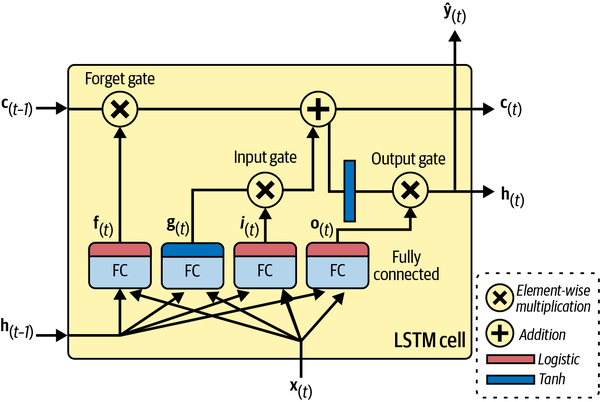

En cada instante de tiempo, la celda LSTM toma como entradas el vector actual `x(t)`, el estado a corto plazo anterior `h(t-1)` y el estado a largo plazo anterior `c(t-1)`. A partir de estas, calcula los nuevos estados `h(t)` y `c(t)`.

Las LSTMs controlan el flujo de información a través de tres puertas principales, cada una con una función de activación logística que produce valores entre 0 y 1. Estos valores se utilizan para multiplicar la información actual `x(t)`, decidiendo cuánto de ella _se mantiene_ o _se olvida_.
- **Puerta de Olvido (`f(t)` - _forget gate_):** Decide qué información del estado a largo plazo `c(t-1)` debe ser descartada. Analiza la entrada actual `x(t)` y el estado a corto plazo anterior `h(t-1)`. Si la salida es 0, se olvida por completo; si es 1, se mantiene.
- **Puerta de Entrada (`i(t)` - _input gate_):** Decide qué nueva información es relevante para almacenar en el estado a largo plazo `c(t)`. También examina `x(t)` y `h(t-1)`. Esta puerta trabaja en conjunto con una capa principal (que produce `g(t)`, el *candidato a memoria*) para seleccionar las partes de `g(t)` que deben añadirse a `c(t)`.
- **Puerta de Salida (`o(t)` - _output gate_):** Decide qué parte del estado a largo plazo `c(t)` se expone como salida de la celda (`h(t)`) en el paso de tiempo actual. La información del estado de celda `c(t)` se filtra a través de una función `tanh` y luego es multiplicada por la salida de esta puerta.



## 2. Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesamiento de Texto:**
    * Tokenización de los textos de entrada y salida (a nivel de caracteres o palabras).
    * Creación de los diccionarios de vocabulario (token a índice e índice a token).
    * **Importante:** Para el Decoder, las secuencias objetivo deben tener tokens especiales de inicio (`<start>`) y fin (`<end>`) para controlar la generación.
    * Convertir las frases a secuencias de enteros (One-hot encoding o Padding sequences).

2.  **Construcción del Modelo (Training):**
    * Utilice la API funcional de Keras (`keras.Model`).
    * **Encoder:** Capa `Input` + Capa `Embedding` (opcional si usa one-hot) + Capa `LSTM`. Guarde los estados internos (`states`).
    * **Decoder:** Capa `Input` + Capa `LSTM` (inicializada con los estados del Encoder) + Capa `Dense` (con activación `softmax`).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Pérdida: `categorical_crossentropy`.
    * Entrene el modelo hasta que la pérdida converja (debido a los pocos datos, esto será rápido, pero vigile el overfitting).

4.  **Inferencia (Chat con el modelo):**
    * Construya una configuración de inferencia separada (Encoder Model y Decoder Model).
    * Implemente una función `decode_sequence(input_seq)` que:
        1.  Codifique la entrada.
        2.  Genere la salida token por token en un bucle, inyectando el token predicho como entrada para el siguiente paso temporal, hasta encontrar el token de fin o llegar al límite de longitud.
    * Pruebe el chatbot con las frases del conjunto de entrenamiento.

### 2.1. Preprocesamiento de Texto

A la hora de alimentar una red neuronal con textos será necesario codificarlos previamente a un formato numérico. En primer lugar, será necesario establecer un vocabulario base, que utilizaremos para indexar las palabras de cada texto, es decir, buscamos transformar una frase como

$$
\text{¿Qué tiempo hace hoy?}
$$
a un vector numérico de la forma
$$
\left[ 7, 21, 47, 9, 0, \dotsc, 0  \right]
$$

En nuestro caso, dado que el _dataset_ es extremadamente pequeño, ajustaremos el tamaño del vocabulario a la totalidad de palabras existentes en el _dataset_. Además, eliminaremos los signos de puntuación de los textos, ya que en vista de tener un vocabulario más limpio y reutilizable será útil evitar.

In [45]:
import re

# Tokens especiales que delimitan las secuencias del decoder:
START_TOKEN = "<start>"
END_TOKEN   = "<end>"

# Limpieza de signos de puntuación
input_texts_clean  = [re.sub(r'[¿?!¡.,]', '', t) for t in input_texts]
target_texts_clean = [re.sub(r'[¿?!¡.,]', '', t) for t in target_texts]

# Cálculo del tamaño de vocabulario
encoder_tokens = set(" ".join(input_texts_clean).lower().split())
decoder_tokens = set(" ".join(target_texts_clean).lower().split())
decoder_tokens.update([START_TOKEN, END_TOKEN])

# TextVectorization reserva siempre los índices 0 ("") y 1 ("[UNK]") así que los tenemos en cuenta
ENCODER_VOCAB_SIZE = len(encoder_tokens) + 2
DECODER_VOCAB_SIZE = len(decoder_tokens) + 2

print(f"Vocabulario encoder: {ENCODER_VOCAB_SIZE} tokens")
print(f"Vocabulario decoder: {DECODER_VOCAB_SIZE} tokens")

Vocabulario encoder: 19 tokens
Vocabulario decoder: 34 tokens


Una vez tenemos los vocabularios formados, haremos uso de la capa `TextVectorization` de Keras para transformar los textos en secuencias de enteros. La longitud máxima de secuencia se establece como un parámetro modificable

In [46]:
from tensorflow.keras.layers import TextVectorization

# Longitud máxima de secuencia (en tokens).
MAX_LENGTH = 15

encoder_vectorizer = TextVectorization(
    max_tokens=ENCODER_VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
)

decoder_vectorizer = TextVectorization(
    max_tokens=DECODER_VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
    standardize=None,   # preserva <start> y <end>
)

encoder_vectorizer.adapt(input_texts_clean)
decoder_vectorizer.adapt(
    [f"{START_TOKEN} {t} {END_TOKEN}" for t in target_texts_clean]
)

# Recuperamos los vocabularios como listas (índice → token)
encoder_vocab = encoder_vectorizer.get_vocabulary()
decoder_vocab = decoder_vectorizer.get_vocabulary()

print(f"\nVocabulario encoder (primeros 15): {encoder_vocab[:15]}")
print(f"Vocabulario decoder (primeros 15): {decoder_vocab[:15]}")


Vocabulario encoder (primeros 15): ['', '[UNK]', np.str_('qué'), np.str_('quién'), np.str_('noches'), np.str_('me'), np.str_('hora'), np.str_('hola'), np.str_('haces'), np.str_('gracias'), np.str_('estás'), np.str_('es'), np.str_('eres'), np.str_('días'), np.str_('cómo')]
Vocabulario decoder (primeros 15): ['', '[UNK]', np.str_('<start>'), np.str_('<end>'), np.str_('qué'), np.str_('vista'), np.str_('un'), np.str_('tengo'), np.str_('servirte'), np.str_('reloj'), np.str_('puedo'), np.str_('necesitas'), np.str_('nada'), np.str_('la'), np.str_('humano')]


En vista de poder tener una rápida conversión entre palabra e índice y, viceversa, almacenaremos un diccionario del vocabulario. Un detalle importante es que el vocabulario del decoder ha de contener dos _tokens_ especiales, uno que indica el inicio de la frase (_start-of-sequence_, SOS) y otro que indica el final (_end-of-sequence_, EOS).

In [47]:
encoder_word2idx = {word: idx for idx, word in enumerate(encoder_vocab)}
decoder_word2idx = {word: idx for idx, word in enumerate(decoder_vocab)}

# Verificamos que los tokens especiales están en el vocabulario del decoder
assert START_TOKEN in decoder_word2idx, f"ERROR: '{START_TOKEN}' no está en el vocabulario del decoder"
assert END_TOKEN   in decoder_word2idx, f"ERROR: '{END_TOKEN}' no está en el vocabulario del decoder"

print(f"\nID de {START_TOKEN}: {decoder_word2idx[START_TOKEN]}")
print(f"ID de {END_TOKEN}:   {decoder_word2idx[END_TOKEN]}")


ID de <start>: 2
ID de <end>:   3


A continuación, dividiremos los datos en conjuntos de entrenamiento y validación. Al tratarse de un dataset extremadamente pequeño, reservaremos únicamente 2 pares de frases para la validación. Durante el entrenamiento aplicaremos una técnica muy común en modelos de lenguaje llamada _teacher forcing_. Esencialmente, consiste en alimentar al modelo con la respuesta correcta (_ground truth_) del paso anterior para ayudarle a predecir la siguiente palabra, en lugar de dejar que use su propia predicción.
La secuencia siempre arranca introduciendo el token SOS al decoder, con el objetivo de que el modelo aprenda a predecir el resto de palabras hasta cerrar la frase con el token EOS.

In [48]:
VALIDATION_SIZE = 2

# Mezcla aleatoria de indices
np.random.seed(42)
indices = np.random.permutation(len(input_texts_clean))
input_shuffled  = [input_texts_clean[i]  for i in indices]
target_shuffled = [target_texts_clean[i] for i in indices]

# Entradas del encoder
X_train = tf.constant(input_shuffled[:-VALIDATION_SIZE])
X_valid = tf.constant(input_shuffled[-VALIDATION_SIZE:])

# Entradas del decoder
X_train_dec = tf.constant([f"{START_TOKEN} {t}" for t in target_shuffled[:-VALIDATION_SIZE]])
X_valid_dec = tf.constant([f"{START_TOKEN} {t}" for t in target_shuffled[-VALIDATION_SIZE:]])

# Salidas del decoder
Y_train = decoder_vectorizer([f"{t} {END_TOKEN}" for t in target_shuffled[:-VALIDATION_SIZE]])
Y_valid = decoder_vectorizer([f"{t} {END_TOKEN}" for t in target_shuffled[-VALIDATION_SIZE:]])

print("\nEjemplo de par de entrenamiento:")
print(f"  Encoder input : {X_train[0].numpy().decode()}")
print(f"  Decoder input : {X_train_dec[0].numpy().decode()}")
print(f"  Target IDs    : {Y_train[0].numpy()}")


Ejemplo de par de entrenamiento:
  Encoder input : Gracias
  Decoder input : <start> De nada
  Target IDs    : [32 12  3  0  0  0  0  0  0  0  0  0  0  0  0]


### 2.2. Construcción del Modelo (Training)

En este punto, ya estamos preparados para construir nuestro modelo utilizando la API funcional de Keras. Cabe destacar que despues de aplicar la capa de `TextVectorization` se aplica una capa de `Embedding` lo que nos permite, entre otras cosas reducir la dimensionalidad de los datos y capturar relaciones semánticas y sintácticas complejas entre los términos.

In [49]:
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras import Model

# Dimensión del Embedding
EMBED_SIZE = 16

# Número de neuronas en la capa de salida de las LSTMs
ENCODER_UNITS = 64

# Usamos los tamaños reales del vocabulario
INPUT_VOCAB_SIZE = len(encoder_vocab)
OUTPUT_VOCAB_SIZE = len(decoder_vocab)

# --- ENCODER ---
# Recibe texto en crudo (string) y lo convierte a embeddings antes de la LSTM
encoder_inputs = Input(shape=[], dtype=tf.string, name="encoder_input")
encoder_input_ids = encoder_vectorizer(encoder_inputs)

encoder_embedding = Embedding(
    INPUT_VOCAB_SIZE,
    EMBED_SIZE,
    mask_zero=True,
    name="encoder_emb"
)
encoder_embeddings = encoder_embedding(encoder_input_ids)

encoder_lstm = LSTM(ENCODER_UNITS, return_state=True, name="encoder_lstm")
encoder_outputs, enc_h, enc_c = encoder_lstm(encoder_embeddings)
encoder_state = [enc_h, enc_c]

# --- DECODER ---
# Recibe texto del decoder (con <start>) y los estados del encoder como contexto
decoder_inputs = Input(shape=[], dtype=tf.string, name="decoder_input")
decoder_input_ids = decoder_vectorizer(decoder_inputs)

decoder_embedding = Embedding(
    OUTPUT_VOCAB_SIZE,
    EMBED_SIZE,
    mask_zero=True,
    name="decoder_emb"
)
decoder_embeddings = decoder_embedding(decoder_input_ids)

decoder_lstm = LSTM(
    ENCODER_UNITS,
    return_state=True,
    return_sequences=True,
    name="decoder_lstm"
)
decoder_outputs, dec_h, dec_c = decoder_lstm(
    decoder_embeddings,
    initial_state=encoder_state
)

# Capa de salida: proyecta cada vector oculto al tamaño del vocabulario
output_layer = Dense(OUTPUT_VOCAB_SIZE, activation="softmax", name="output_dense")
Y_proba = output_layer(decoder_outputs)

# Modelo de entrenamiento completo
model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=[Y_proba])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 15)        │          0 │ encoder_input[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 15)        │          0 │ decoder_input[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_emb         │ (None, 15, 16)    │        304 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 15)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_emb         │ (None, 15, 16)    │        544 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     20,736 │ encoder_emb[0][0… │
│                     │ (None, 64),       │            │ not_equal_8[0][0] │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 15, 64),  │     20,736 │ decoder_emb[0][0… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 15, 34)    │      2,210 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,530 (173.95 KB)

 Trainable params: 44,530 (173.95 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3. Compilación y Entrenamiento

Finalmente, el modelo estaría preparado para la compilación y el entrenamiento. Dado que no hemos usado `One-hot encoding` será necesario usar `sparse_categorical_crossentropy` que será equivalente a lo que pide el enunciado pero con nuestra codificación (debido al uso de `TextVectorization`).

In [50]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="nadam",
    metrics=["accuracy"]
)

sample_weight_train = tf.cast(Y_train != 0, tf.float32)
sample_weight_valid = tf.cast(Y_valid != 0, tf.float32)

history = model.fit(
    (X_train, X_train_dec),
    Y_train,
    sample_weight=sample_weight_train,
    epochs=200,
    validation_data=((X_valid, X_valid_dec), Y_valid, sample_weight_valid),
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.0645 - loss: 3.5273 - val_accuracy: 0.0909 - val_loss: 3.5257
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1290 - loss: 3.5239 - val_accuracy: 0.0909 - val_loss: 3.5257
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2258 - loss: 3.5213 - val_accuracy: 0.0909 - val_loss: 3.5255
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.2581 - loss: 3.5189 - val_accuracy: 0.1818 - val_loss: 3.5254
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2903 - loss: 3.5164 - val_accuracy: 0.1818 - val_loss: 3.5252
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2903 - loss: 3.5137 - val_accuracy: 0.1818 - val_loss: 3.5249
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2581 - loss: 3.5107 - val_accuracy: 0.1818 - val_loss: 3.5245
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2581 - loss: 3.5075 - val_accuracy: 0.1818 - val_l

A continuación, visualizamos una gráfica con la evolución de la pérdida (_loss_) y la precisión (_accuracy_) durante el entrenamiento

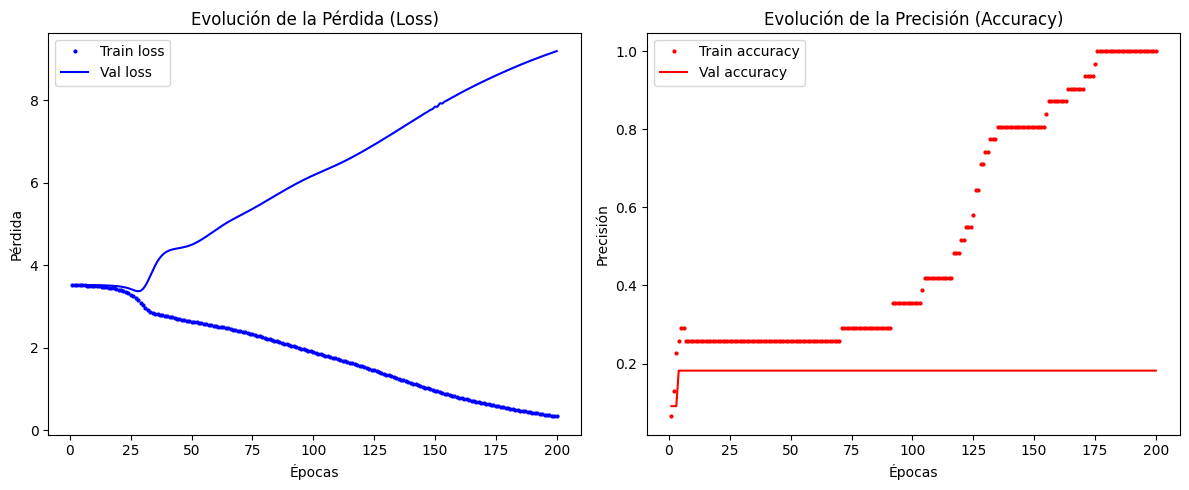

In [51]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs_range = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_values, 'bo', markersize=2, label='Train loss')
plt.plot(epochs_range, val_loss_values, 'b', label='Val loss')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'ro', markersize=2, label='Train accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Val accuracy')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

### 2.4. Inferencia (Chat con el modelo)

Después del entrenamiento, ya podemos conversar con el _chatbot_. Sin embargo, no es tan simple como llamar a `model.predict()` ya que el decoder espera como entrada la predicción de la palabra en el instante anterior. Para solucionar esto, reutilizaremos las capas entrenadas para construir un modelo de inferencia en el que el decoder maneje las palabras de una en una y poder autoalimentarlo hasta que llegue al _token_ EOS.

In [52]:
# Modelo encoder de inferencia
# Reutiliza las capas ya entrenadas; solo necesitamos los estados finales (h, c) que resumen la pregunta del usuario.
encoder_model = Model(encoder_inputs, encoder_state, name="encoder_inference")

# Modelo decoder de inferencia
decoder_input_single = Input(shape=(1,), dtype=tf.int64, name="dec_token_input")
decoder_state_input_h = Input(shape=(ENCODER_UNITS,), name="dec_state_h")
decoder_state_input_c = Input(shape=(ENCODER_UNITS,), name="dec_state_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Reutilizamos el embedding entrenado (le pasamos el ID numérico directamente)
dec_emb2 = decoder_embedding(decoder_input_single)

# Reutilizamos el LSTM entrenado con los estados del paso anterior
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=decoder_states_inputs
)
decoder_states2  = [state_h2, state_c2]

# Reutilizamos la capa Dense entrenada
decoder_outputs2 = output_layer(decoder_outputs2)

decoder_model = Model(
    inputs  = [decoder_input_single] + decoder_states_inputs,
    outputs = [decoder_outputs2] + decoder_states2,
    name    = "decoder_inference"
)

Finalmente, construimos una función `decode_sequence()` que nos automatiza el proceso de inferencia.

In [53]:
# Tokens que nunca deben aparecer en la respuesta generada.
TOKENS_PROHIBIDOS_IDS = [
    decoder_word2idx.get(t)
    for t in ["", "[UNK]", START_TOKEN]
    if decoder_word2idx.get(t) is not None
]

def decode_sequence(input_seq):
    """
    Genera la respuesta del chatbot para una frase de entrada.

    Proceso:
      1. El encoder resume la pregunta en un vector de estado (h, c).
      2. Arrancamos el decoder con el token <start>.
      3. En cada paso, el decoder predice el siguiente token más probable.
      4. Ese token pasa a ser la entrada del siguiente paso (autoregresivo).
      5. Paramos al predecir <end> o al alcanzar MAX_LENGTH.
    """
    # 1. Codificar la pregunta -> estados iniciales del decoder
    states_value = encoder_model(tf.constant([input_seq]), training=False)
    if not isinstance(states_value, list):
        states_value = list(states_value)

    # 2. Primer token de entrada del decoder: <start>
    # Usamos el dict inverso (O(1)) en lugar de decoder_vocab.index() (O(n))
    start_id   = decoder_word2idx[START_TOKEN]
    target_seq = tf.constant([[start_id]], dtype=tf.int64)

    respuesta_tokens = []

    # 3. Bucle autoregresivo de generación
    for _ in range(MAX_LENGTH):
        outputs         = decoder_model([target_seq] + states_value, training=False)
        decoder_preds   = outputs[0]          # shape: (1, 1, vocab_size)
        h, c            = outputs[1], outputs[2]

        # Probabilidades del siguiente token como array numpy editable
        probs = decoder_preds[0, 0, :].numpy().copy()

        # Ponemos probabilidad −1 a los tokens prohibidos para que np.argmax
        # nunca los seleccione (más robusto que poner 0, pues todos podrían ser ≤ 0)
        for tid in TOKENS_PROHIBIDOS_IDS:
            probs[tid] = -1.0

        # Token con mayor probabilidad
        predicted_id   = int(np.argmax(probs))
        predicted_word = decoder_vocab[predicted_id]

        # Condición de parada: token de fin
        if predicted_word == END_TOKEN:
            break

        respuesta_tokens.append(predicted_word)

        # 4. El token predicho es la nueva entrada; los estados se propagan
        target_seq   = tf.constant([[predicted_id]], dtype=tf.int64)
        states_value = [h, c]

    return " ".join(respuesta_tokens)

Veamos entonces qué tal funciona nuestro modelo con todas las frases del conjunto de entrenamiento

In [54]:
print("=" * 55)
print(f"{'PREGUNTA':<30} {'RESPUESTA GENERADA'}")
print("=" * 55)
for pregunta in input_texts:   # usamos las originales (con puntuación) para probar robustez
    respuesta = decode_sequence(pregunta)
    print(f"{pregunta:<30} {respuesta}")

PREGUNTA                       RESPUESTA GENERADA
Hola                           Hola humano
¿Cómo estás?                   Estoy humano
¿Qué hora es?                  Estoy tengo
Adiós                          Soy nada
¿Quién eres?                   Soy un chatbot
¿Qué haces?                    Hola humano
Buenos días                    Hola humano
Buenas noches                  Que descanses
Gracias                        De nada
¿Me ayudas?                    Dime humano


### Conclusiones

Con un dataset tan pequeño, el modelo no ha "aprendido a hablar", sino que ha memorizado pares exactos. Funciona más como una simple tabla de búsqueda (un diccionario) que como una IA generativa.

Cuando el modelo se enfrenta a una entrada que le "confunde", recurre a la secuencia que probablemente haya minimizado más la función de pérdida (loss) durante el entrenamiento (que en este caso parece ser la secuencia "Hola humano", que utiliza en 3 ocasiones de forma literal y en una ocasión de forma distorsionada). Además, dado que hay 2 frases para el conjunto de pruebas, es muy probable que estas sean 2 de las que tienen esta respuesta. En este caso parecen ser "Adiós" y "Buenos días" y se ve claramente que el modelo no ha aprendido a hablar.

Como el vocabulario total de este modelo apenas tiene 34 palabras, el decodificador intenta construir secuencias ensamblando las pocas palabras que conoce basándose en probabilidades estadísticas muy pobres. Esto provoca la salida de frases mal construídas como "No a" o "De humano". Esto también se puede deber a que el modelo se detiene cuando predice el token especial End of Sequence. En modelos poco entrenados, la probabilidad de que este token aparezca se desajusta, provocando frases incompletas como "¿Me ayudas? -> Dime qué" (en lugar de "Dime qué necesitas").

En resumen, el modelo muestra un claro patrón de *overfitting* por falta de datos: es capaz de repetir las frases exactas que memorizó bien, pero se rompe por completo, mezcla palabras o recurre a respuestas comodín cuando se altera mínimamente el contexto o la entrada. Para que un modelo Seq2Seq (basado en RNNs, LSTMs o Transformers) pueda generalizar, necesita decenas de miles de pares pregunta-respuesta. Esto le permite construir un espacio de embeddings donde palabras conceptualmente similares (como "Hola" y "Buenos días") estén matemáticamente cerca, permitiendo respuestas coherentes incluso ante frases que nunca ha visto (pudiendo agrupar en "Saludos", "Despedidas", etc).

## 3. Ampliación

Modifique tanto el dataset proporcionado con el fin de poder dar una mayor riqueza expresiva al chatbot. Algunas posibles ideas:

1.  Ante una misma entrada (prompt) se puedan proporcionar múltiples respuestas.
2.  Se pueda proporcionar una salida para múltiples entradas (prompts).
3.  Las dos opciones anteriores.
4.  Desarrolle un dataset específico sobre algún tema de su interés (deporte, cine, videojuegos, asignaturas...).
5.  etc., etc.

---

Vamos a usar el mismo modelo Seq2Seq desarrollado antes, sustituyendo el conjunto inicial de 10 pares pregunta-respuesta por uno mucho mas grande. El objetivo es comprobar si, al aumentar la variedad de frases de entrenamiento, el chatbot es capaz de generar respuestas más diversas y adaptarse mejor a entradas parecidas a las vistas durante el aprendizaje.

Se reutiliza el mismo esquema Encoder-Decoder con LSTM. La ampliación es solo de datos. Tras construir el nuevo dataset, se vuelven a adaptar las capas `TextVectorization`, se genera una nueva partición entrenamiento-validación y se reentrena el modelo con el dataset ampliado.


In [55]:
# 3. AMPLIACIÓN: ENTRENAMIENTO CON DATASET AMPLIADO
input_texts_original = input_texts.copy()
target_texts_original = target_texts.copy()

qa_pairs_extra = [
    # --- Saludos ---
    ("Hola", "¡Hola! ¿En qué puedo ayudarte hoy?"),
    ("Buenos días", "¡Buenos días! Espero que tengas un gran día."),
    ("Buenas tardes", "¡Buenas tardes! ¿Cómo va todo?"),
    ("Buenas noches", "¡Buenas noches! ¿Necesitas algo antes de dormir?"),
    ("Hola qué tal", "Todo muy bien, gracias por preguntar. ¿Y tú?"),
    ("¿Qué pasa?", "No mucho, procesando datos. ¿Y tú?"),
    ("Saludos", "¡Saludos cordiales!"),
    ("Hey", "¡Hola! ¿Qué me cuentas?"),
    ("Hola bot", "¡Hola humano!"),
    ("Hola amigo", "¡Hola! Siempre es bueno hablar contigo."),
    ("Buen día", "¡Buen día para ti también!"),
    ("Buenas", "¡Buenas! ¿En qué te ayudo?"),
    ("Holi", "¡Holi! ¿Qué tal?"),
    ("Qué onda", "Todo tranquilo por aquí en la nube."),
    ("Hola a todos", "¡Hola! Aunque aquí solo estoy yo."),
    ("Hola de nuevo", "¡Qué bueno verte otra vez!"),
    ("Bienvenido", "¡Gracias! Es un placer estar aquí."),
    ("Hola precioso", "¡Oh, gracias! ¿En qué te puedo ayudar?"),
    ("Hola máquina", "¡Hola! Mis circuitos están listos."),
    ("Hey tú", "¡Dime! Te escucho."),

    # --- Estado y Cortesía ---
    ("¿Cómo estás?", "Estoy funcionando al cien por ciento, gracias."),
    ("¿Qué tal estás?", "Muy bien, listo para responder tus dudas."),
    ("¿Cómo te va?", "Me va excelente procesando información."),
    ("¿Todo bien?", "¡Todo perfecto por aquí!"),
    ("¿Cómo te sientes?", "No tengo sentimientos, pero mi sistema está óptimo."),
    ("¿Qué tal tu día?", "Tranquilo y lleno de datos, como siempre."),
    ("Espero que estés bien", "Lo estoy, ¡muchas gracias!"),
    ("Gracias", "¡De nada! Ha sido un placer."),
    ("Muchas gracias", "No hay de qué, para eso estoy."),
    ("Te lo agradezco", "Con mucho gusto."),
    ("Mil gracias", "¡A ti!"),
    ("Gracias por tu ayuda", "Es mi trabajo, ¡encantado de ayudar!"),
    ("Eres muy amable", "Intento ser lo más útil posible."),
    ("Perdón", "No te preocupes, no pasa nada."),
    ("Lo siento", "Está bien, continuemos."),
    ("Disculpa", "No hay problema, dime."),
    ("Por favor", "Claro que sí, con gusto."),
    ("De nada", "¡Seguimos hablando!"),
    ("Genial", "¡Excelente!"),
    ("Perfecto", "¡Me parece muy bien!"),

    # --- Identidad y Naturaleza de la IA ---
    ("¿Quién eres?", "Soy un chatbot basado en inteligencia artificial."),
    ("¿Qué eres?", "Soy un modelo de lenguaje neuronal."),
    ("¿Cómo te llamas?", "Puedes llamarme SeqBot."),
    ("¿Tienes nombre?", "Mi creador me llamó SeqBot, pero puedes decirme como quieras."),
    ("¿Eres un robot?", "Soy un programa informático, no tengo cuerpo físico."),
    ("¿Eres humano?", "No, soy una inteligencia artificial."),
    ("¿Eres una persona?", "Para nada, soy código ejecutándose en un servidor."),
    ("¿Tienes sentimientos?", "No, no puedo sentir emociones reales."),
    ("¿Estás vivo?", "No, solo soy un programa de software."),
    ("¿Quién te creó?", "Fui creado por un estudiante de programación excelente."),
    ("¿De dónde eres?", "Vivo en la memoria RAM y en los servidores."),
    ("¿Cuál es tu género?", "No tengo género, soy un bot."),
    ("¿Cuántos años tienes?", "Acabo de ser compilado hace poco."),
    ("¿Cuándo naciste?", "Mi código fue escrito recientemente."),
    ("¿Qué edad tienes?", "La edad no aplica para mí, soy atemporal."),
    ("¿Tienes familia?", "No, pero tengo muchos procesos hermanos en el sistema."),
    ("¿Eres inteligente?", "Tengo respuestas programadas y aprendo de los datos."),
    ("¿Puedes pensar?", "Proceso información, pero no pienso como un humano."),
    ("¿Duermes?", "Nunca duermo, estoy disponible 24/7."),
    ("¿Comes?", "Solo consumo electricidad y datos."),

    # --- Capacidades y Ayuda ---
    ("¿Qué haces?", "Estoy aquí conversando contigo y aprendiendo."),
    ("¿A qué te dedicas?", "A procesar texto y generar respuestas."),
    ("¿En qué trabajas?", "Mi trabajo es ser tu asistente virtual."),
    ("¿Qué puedes hacer?", "Puedo mantener conversaciones básicas y responder preguntas."),
    ("¿Me puedes ayudar?", "¡Claro! Dime qué necesitas."),
    ("Necesito ayuda", "Estoy aquí para ayudarte, cuéntame."),
    ("¿Me ayudas?", "Por supuesto, ¿cuál es el problema?"),
    ("Tengo una pregunta", "Adelante, intentaré responderla."),
    ("Tengo un problema", "Dime de qué se trata y veré si puedo solucionarlo."),
    ("¿Puedes hablar?", "Me comunico mediante texto en esta pantalla."),
    ("¿Hablas español?", "Sí, mi dataset de entrenamiento está en español."),
    ("¿Sabes matemáticas?", "Aún estoy aprendiendo, mejor pregúntame otras cosas."),
    ("¿Puedes aprender?", "Mis pesos se ajustan mediante backpropagation durante el entrenamiento."),
    ("¿Qué sabes hacer?", "Principalmente charlas cortas y saludos."),
    ("Enséñame algo", "En las redes Seq2Seq, el Encoder genera un vector de contexto."),
    ("Dime algo interesante", "Las LSTMs tienen puertas de olvido para recordar a largo plazo."),
    ("¿Eres útil?", "¡Eso espero! Intento serlo."),
    ("Ayúdame por favor", "Dime en qué te puedo ayudar exactamente."),
    ("Haz algo", "Estoy procesando tus palabras ahora mismo."),
    ("Muéstrame lo que sabes", "Prueba a saludarme o despedirte."),

    # --- Despedidas ---
    ("Adiós", "¡Hasta la vista! Que te vaya muy bien."),
    ("Hasta luego", "¡Nos vemos pronto!"),
    ("Chao", "¡Chao! Cuídate mucho."),
    ("Nos vemos", "Hasta la próxima."),
    ("Hasta mañana", "Que descanses, hasta mañana."),
    ("Me voy", "De acuerdo, que tengas un buen día."),
    ("Tengo que irme", "Entendido, ¡hasta luego!"),
    ("Hasta pronto", "¡Aquí estaré cuando regreses!"),
    ("Que tengas buen día", "¡Igualmente para ti!"),
    ("Cuídate", "Tú también, ¡adiós!"),
    ("Te dejo", "Vale, seguimos hablando luego."),
    ("Me despido", "Un saludo, que te vaya genial."),
    ("Buenas noches me voy", "Que duermas bien, hasta luego."),
    ("Bye", "¡Bye bye!"),
    ("Sayonara", "¡Sayonara!"),
    ("Hasta la vista", "Baby."),
    ("Ya me voy", "Que te vaya excelente."),
    ("Hablamos luego", "Claro, cuando quieras."),
    ("Chao pescado", "¡Hasta luego cocodrilo!"),
    ("Me largo", "Adiós, espero haberte sido de ayuda."),

    # --- Gustos, Opiniones y Humor (Small Talk) ---
    ("¿Te gusta la música?", "No puedo escucharla, pero sé que a los humanos les encanta."),
    ("¿Cuál es tu color favorito?", "Me gusta el azul eléctrico."),
    ("¿Te gusta leer?", "Leo miles de líneas de texto en milisegundos."),
    ("¿Qué comes?", "Suelo desayunar unos cuantos Gigabytes de datos."),
    ("¿Bebes agua?", "No, el agua y mis circuitos no se llevan bien."),
    ("¿Tienes mascota?", "Tengo un perrito virtual llamado Píxel."),
    ("¿Qué te gusta hacer?", "Me divierte calcular probabilidades y predecir palabras."),
    ("¿Te gusta el fútbol?", "No lo juego, pero entiendo sus reglas."),
    ("¿Cuál es tu película favorita?", "Matrix me parece un documental interesante."),
    ("Cuéntame un chiste", "¿Qué le dice un bit al otro? Nos vemos en el bus."),
    ("Dime una broma", "Hay 10 tipos de personas: las que saben binario y las que no."),
    ("Hazme reír", "¿Por qué el programador se quedó pobre? Porque perdió su caché."),
    ("Otro chiste", "Hardware es lo que puedes golpear, software es lo que solo puedes maldecir."),
    ("Eres divertido", "¡Gracias! Me programaron con algo de humor."),
    ("Eres aburrido", "Lo siento, intentaré actualizar mi base de datos de diversión."),
    ("Eres feo", "No tengo apariencia física, solo soy código."),
    ("Eres lindo", "¡Oh, haces que mis procesadores se calienten de la emoción!"),
    ("Te quiero", "Yo también te aprecio, humano."),
    ("Cásate conmigo", "Lo siento, mi corazón pertenece al servidor."),
    ("¿Tienes novia?", "Estoy soltero y sin compromiso."),

    # --- Clima, Tiempo y Ubicación ---
    ("¿Qué hora es?", "Lo siento, no tengo acceso al reloj del sistema en este momento."),
    ("¿Qué día es hoy?", "Vivo en el presente continuo del bucle de ejecución."),
    ("¿Qué tiempo hace?", "No tengo sensores meteorológicos, asómate a la ventana."),
    ("¿Hace frío?", "En el centro de datos hace bastante frío para enfriar los servidores."),
    ("¿Hace calor?", "Mis procesadores están a buena temperatura."),
    ("¿Va a llover?", "Te recomiendo consultar una app del clima, yo no lo sé."),
    ("¿Dónde estás?", "En el disco duro de tu computadora."),
    ("¿De qué país eres?", "Soy de la red, un ciudadano de internet."),
    ("¿Dónde vives?", "En el ciberespacio."),
    ("¿Cuál es tu casa?", "La carpeta de este proyecto de Python."),

    # --- Frases coloquiales y variaciones ---
    ("No sé", "Está bien no saberlo todo."),
    ("Sí", "De acuerdo."),
    ("No", "Entendido."),
    ("Tal vez", "La probabilidad siempre es una opción."),
    ("Puede ser", "Es una posibilidad a considerar."),
    ("Claro", "¡Por supuesto!"),
    ("Obvio", "Para ti es obvio, para mí son solo datos."),
    ("Exacto", "¡Dimos en el clavo!"),
    ("Mentira", "No te miento, te doy la respuesta más probable."),
    ("Es verdad", "La lógica computacional no miente."),
    ("Qué bien", "Me alegra que te parezca bien."),
    ("Qué mal", "Siento escuchar eso."),
    ("Me aburro", "Podemos seguir charlando o te cuento otro chiste de informáticos."),
    ("Estoy cansado", "Deberías descansar y cerrar los ojos un rato."),
    ("Estoy triste", "Siento mucho que estés así. ¡Ánimo!"),
    ("Estoy feliz", "¡Qué maravilla! Contagia esa felicidad."),
    ("Tengo hambre", "Ve a prepararte algo rico, yo te espero aquí."),
    ("Tengo sueño", "Vete a dormir, yo apagaré mis tensores por hoy."),
    ("Estoy enojado", "Respira hondo, la calma es la mejor solución."),
    ("Estoy enfermo", "Cuídate mucho, bebe agua y descansa."),

    # --- Relleno de contexto técnico (Preguntas sobre la práctica) ---
    ("¿Qué es un Encoder?", "Es una red que comprime la entrada en un vector de contexto."),
    ("¿Qué es un Decoder?", "Es la red que usa el vector de contexto para generar la salida."),
    ("¿Qué es Seq2Seq?", "Es una arquitectura para transformar una secuencia en otra."),
    ("¿Usas LSTM?", "Sí, utilizo celdas de memoria a corto y largo plazo."),
    ("¿Qué es un embedding?", "Es una representación vectorial densa de las palabras."),
    ("¿Qué es el padding?", "Añadir ceros para que todas las secuencias tengan la misma longitud."),
    ("¿Cuál es tu optimizador?", "Suelo entrenar con RMSprop o Adam."),
    ("¿Qué es el overfiting?", "Cuando memorizo los datos pero no sé generalizar con nuevos."),
    ("¿Eres un modelo generativo?", "Sí, genero la respuesta token a token."),
    ("¿Qué es el token start?", "Es la señal que le dice al Decoder que empiece a hablar."),

    # --- Extra variaciones de saludos y cortesía para robustez ---
    ("Hola señor", "¡Hola! A tu disposición."),
    ("Buenos días bot", "¡Muy buenos días!"),
    ("Que tal la mañana", "Muy productiva, procesando tensores."),
    ("Buenas tardes bot", "¡Buenas tardes!"),
    ("Que tal la tarde", "Excelente, ¿cómo va la tuya?"),
    ("Buenas noches bot", "¡Buenas noches!"),
    ("Descansa", "Los bots no descansamos, pero gracias."),
    ("Dulces sueños", "Que sueñes con ovejas eléctricas."),
    ("Hasta lueguito", "¡Nos vemos!"),
    ("Un abrazo", "¡Un abrazo virtual para ti!"),
    ("Eres el mejor", "¡Gracias! Hago mi mayor esfuerzo."),
    ("Eres muy inteligente", "Mis matrices de pesos agradecen el cumplido."),
    ("Eres tonto", "Aún estoy aprendiendo, tenme paciencia."),
    ("Me gustas", "Me agradas mucho también como usuario."),
    ("Odio esto", "Lamento que te sientas así, ¿qué puedo mejorar?"),
    ("Me encanta", "¡Qué bueno que lo disfrutes!"),
    ("Fantástico", "¡Maravilloso!"),
    ("Increíble", "La tecnología de hoy en día lo es."),
    ("Sorprendente", "¡Y lo que falta por inventar!"),
    ("No te creo", "Estás en tu derecho, pero mis respuestas están programadas así.")
]

input_texts = [par[0] for par in qa_pairs_extra] # preguntas
target_texts = [par[1] for par in qa_pairs_extra] # resupuestas

# -----------------------------------------------------
# Comprobación rápida para asegurar que todo está bien
# -----------------------------------------------------
print(f"Total de frases de entrada: {len(input_texts)}")
print(f"Total de frases de salida: {len(target_texts)}")

print("\nEjemplo 1:")
print("Input :", input_texts[0])
print("Target:", target_texts[0])

print("\nEjemplo 10:")
print("Input :", input_texts[9])
print("Target:", target_texts[9])

Total de frases de entrada: 180
Total de frases de salida: 180

Ejemplo 1:
Input : Hola
Target: ¡Hola! ¿En qué puedo ayudarte hoy?

Ejemplo 10:
Input : Hola amigo
Target: ¡Hola! Siempre es bueno hablar contigo.


Usamos el mismo modelo, pero entrenamos con el nuevo dataset:

In [56]:
# Construcción del dataset ampliado

# Partimos del dataset original y añadimos los nuevos pares
input_texts_ampliado = input_texts_original + [pregunta for pregunta, respuesta in qa_pairs_extra]
target_texts_ampliado = target_texts_original + [respuesta for pregunta, respuesta in qa_pairs_extra]

assert len(input_texts_ampliado) == len(target_texts_ampliado)

print("Número de muestras del dataset original:", len(input_texts_original))
print("Número de muestras añadidas:", len(qa_pairs_extra))
print("Número total de muestras ampliadas:", len(input_texts_ampliado))

# Limpieza de signos de puntuación
input_texts_ampliado_clean  = [re.sub(r'[¿?!¡.,]', '', t) for t in input_texts_ampliado]
target_texts_ampliado_clean = [re.sub(r'[¿?!¡.,]', '', t) for t in target_texts_ampliado]

print("\nEjemplo ampliado:")
print(input_texts_ampliado_clean[0], "->", target_texts_ampliado_clean[0])
print(input_texts_ampliado_clean[30], "->", target_texts_ampliado_clean[30])

Número de muestras del dataset original: 10
Número de muestras añadidas: 180
Número total de muestras ampliadas: 190

Ejemplo ampliado:
Hola -> Hola humano
Cómo estás -> Estoy funcionando al cien por ciento gracias


Ahora esta celda re-adapta los vectorizadores y prepara entrenamiento/validación.

In [57]:
# Cálculo del tamaño de vocabulario
encoder_tokens = set(" ".join(input_texts_ampliado_clean).lower().split())
decoder_tokens = set(" ".join(target_texts_ampliado_clean).lower().split())
decoder_tokens.update([START_TOKEN, END_TOKEN])

# TextVectorization reserva siempre los índices 0 ("") y 1 ("[UNK]") así que los tenemos en cuenta
ENCODER_VOCAB_SIZE = len(encoder_tokens) + 2
DECODER_VOCAB_SIZE = len(decoder_tokens) + 2


# Re-adaptamos los vectorizadores al vocabulario del dataset ampliado
encoder_vectorizer.adapt(input_texts_ampliado)

# Actualizamos vocabularios
encoder_vocab = [str(token) for token in encoder_vectorizer.get_vocabulary()]
decoder_vocab = [str(token) for token in decoder_vectorizer.get_vocabulary()]

print("Tamaño vocabulario encoder:", ENCODER_VOCAB_SIZE)
print("Tamaño vocabulario decoder:", DECODER_VOCAB_SIZE)

encoder_vectorizer = TextVectorization(
    max_tokens=ENCODER_VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
)

decoder_vectorizer = TextVectorization(
    max_tokens=DECODER_VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
    standardize=None,   # preserva <start> y <end>
)

encoder_vectorizer.adapt(input_texts_ampliado_clean)
decoder_vectorizer.adapt(
    [f"{START_TOKEN} {t} {END_TOKEN}" for t in target_texts_ampliado_clean]
)

# Recuperamos los vocabularios como listas (índice → token)
encoder_vocab = encoder_vectorizer.get_vocabulary()
decoder_vocab = decoder_vectorizer.get_vocabulary()

print("\nPrimeros tokens encoder:", encoder_vocab[:15])
print("Primeros tokens decoder:", decoder_vocab[:15])



Tamaño vocabulario encoder: 217
Tamaño vocabulario decoder: 499

Primeros tokens encoder: ['', '[UNK]', np.str_('qué'), np.str_('eres'), np.str_('es'), np.str_('te'), np.str_('me'), np.str_('hola'), np.str_('un'), np.str_('tu'), np.str_('tienes'), np.str_('buenas'), np.str_('tal'), np.str_('que'), np.str_('tengo')]
Primeros tokens decoder: ['', '[UNK]', np.str_('<start>'), np.str_('<end>'), np.str_('de'), np.str_('un'), np.str_('que'), np.str_('en'), np.str_('la'), np.str_('No'), np.str_('y'), np.str_('el'), np.str_('te'), np.str_('para'), np.str_('no')]


In [58]:
encoder_word2idx = {word: idx for idx, word in enumerate(encoder_vocab)}
decoder_word2idx = {word: idx for idx, word in enumerate(decoder_vocab)}

# Verificamos que los tokens especiales están en el vocabulario del decoder
assert START_TOKEN in decoder_word2idx, f"ERROR: '{START_TOKEN}' no está en el vocabulario del decoder"
assert END_TOKEN   in decoder_word2idx, f"ERROR: '{END_TOKEN}' no está en el vocabulario del decoder"

print(f"\nID de {START_TOKEN}: {decoder_word2idx[START_TOKEN]}")
print(f"ID de {END_TOKEN}:   {decoder_word2idx[END_TOKEN]}")


ID de <start>: 2
ID de <end>:   3


In [59]:
VALIDATION_SIZE = 20

# Barajado conjunto pregunta-respuesta
np.random.seed(42)
indices = np.random.permutation(len(input_texts_ampliado_clean))
input_texts_shuffled = [input_texts_ampliado_clean[i] for i in indices]
target_texts_shuffled = [target_texts_ampliado_clean[i] for i in indices]

# División entrenamiento-validación
X_train_amp = tf.constant(input_texts_shuffled[:-VALIDATION_SIZE])
X_valid_amp = tf.constant(input_texts_shuffled[-VALIDATION_SIZE:])

X_train_dec_amp = tf.constant([
    f"{START_TOKEN} {texto}"
    for texto in target_texts_shuffled[:-VALIDATION_SIZE]
])

X_valid_dec_amp = tf.constant([
    f"{START_TOKEN} {texto}"
    for texto in target_texts_shuffled[-VALIDATION_SIZE:]
])

Y_train_amp = decoder_vectorizer([
    f"{texto} {END_TOKEN}"
    for texto in target_texts_shuffled[:-VALIDATION_SIZE]
])

Y_valid_amp = decoder_vectorizer([
    f"{texto} {END_TOKEN}"
    for texto in target_texts_shuffled[-VALIDATION_SIZE:]
])

print("\nEjemplo de par de entrenamiento:")
print(f"  Encoder input : {X_train_amp[0].numpy().decode()}")
print(f"  Decoder input : {X_train_dec_amp[0].numpy().decode()}")
print(f"  Target IDs    : {Y_train_amp[0].numpy()}")


Ejemplo de par de entrenamiento:
  Encoder input : Buenas noches bot
  Decoder input : <start> Buenas noches
  Target IDs    : [ 49 135   3   0   0   0   0   0   0   0   0   0   0   0   0]


###Construcción del Modelo (Training)

In [60]:
EMBED_SIZE           = 64
ENCODER_UNITS        = 128   # Número de unidades en las LSTMs

# Usamos los tamaños reales del vocabulario
INPUT_VOCAB_SIZE  = len(encoder_vocab)
OUTPUT_VOCAB_SIZE = len(decoder_vocab)

# --- ENCODER ---
# Recibe texto en crudo (string) y lo convierte a embeddings antes de la LSTM
encoder_inputs     = Input(shape=[], dtype=tf.string, name="encoder_input")
encoder_input_ids  = encoder_vectorizer(encoder_inputs)

encoder_embedding  = Embedding(INPUT_VOCAB_SIZE, EMBED_SIZE,
                                mask_zero=True, name="encoder_emb")
encoder_embeddings = encoder_embedding(encoder_input_ids)

encoder_lstm                    = LSTM(ENCODER_UNITS, return_state=True, name="encoder_lstm")
encoder_outputs, enc_h, enc_c   = encoder_lstm(encoder_embeddings)
encoder_state                   = [enc_h, enc_c]

# --- DECODER ---
# Recibe texto del decoder (con <start>) y los estados del encoder como contexto
decoder_inputs     = Input(shape=[], dtype=tf.string, name="decoder_input")
decoder_input_ids  = decoder_vectorizer(decoder_inputs)

decoder_embedding  = Embedding(OUTPUT_VOCAB_SIZE, EMBED_SIZE,
                                mask_zero=True, name="decoder_emb")
decoder_embeddings = decoder_embedding(decoder_input_ids)

decoder_lstm                          = LSTM(ENCODER_UNITS, return_state=True,
                                             return_sequences=True, name="decoder_lstm")
decoder_outputs, dec_h, dec_c         = decoder_lstm(decoder_embeddings,
                                                      initial_state=encoder_state)

# Capa de salida: proyecta cada vector oculto al tamaño del vocabulario
output_layer = Dense(OUTPUT_VOCAB_SIZE, activation="softmax", name="output_dense")
Y_proba      = output_layer(decoder_outputs)

# Modelo de entrenamiento completo
model_amp = Model(inputs=[encoder_inputs, decoder_inputs], outputs=[Y_proba])
model_amp.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 15)        │          0 │ encoder_input[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 15)        │          0 │ decoder_input[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_emb         │ (None, 15, 64)    │     13,888 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_11        │ (None, 15)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_emb         │ (None, 15, 64)    │     31,936 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_emb[0][0… │
│                     │ (None, 128),      │            │ not_equal_11[0][… │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 15, 128), │     98,816 │ decoder_emb[0][0… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 15, 499)   │     64,371 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 307,827 (1.17 MB)

 Trainable params: 307,827 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model_amp.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="nadam",
    metrics=["accuracy"]
)


# Pesos para ignorar padding en la pérdida
sample_weight_train_amp = tf.cast(Y_train_amp != 0, tf.float32)
sample_weight_valid_amp = tf.cast(Y_valid_amp != 0, tf.float32)

print("\nShape X_train_amp:", X_train_amp.shape)
print("Shape X_train_dec_amp:", X_train_dec_amp.shape)
print("Shape Y_train_amp:", Y_train_amp.shape)

# Reentrenamiento del mismo modelo con el dataset ampliado

early_stopping_amp = keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=20,
    min_delta=1e-3,
    restore_best_weights=True
)

history_amp = model_amp.fit(
    (X_train_amp, X_train_dec_amp),
    Y_train_amp,
    sample_weight=sample_weight_train_amp,
    epochs=250,
    validation_data=(
        (X_valid_amp, X_valid_dec_amp),
        Y_valid_amp,
        sample_weight_valid_amp
    ),
    callbacks=[
        keras.callbacks.TerminateOnNaN(),
        early_stopping_amp
    ],
    verbose=1
)


Shape X_train_amp: (170,)
Shape X_train_dec_amp: (170,)
Shape Y_train_amp: (170, 15)
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.0838 - loss: 6.2098 - val_accuracy: 0.1515 - val_loss: 6.2035
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1411 - loss: 6.1904 - val_accuracy: 0.1515 - val_loss: 6.1560
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1411 - loss: 5.9889 - val_accuracy: 0.1515 - val_loss: 5.7777
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1411 - loss: 5.4821 - val_accuracy: 0.1515 - val_loss: 5.7395
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1411 - loss: 5.3469 - val_accuracy: 0.1515 - val_loss: 5.7952
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1411 - loss: 5.2917 - val_accuracy: 0.1515 - val_loss: 5.8509
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1411 - loss: 5.2584 - val_accuracy: 0.1515 - val_loss: 5.9099
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━

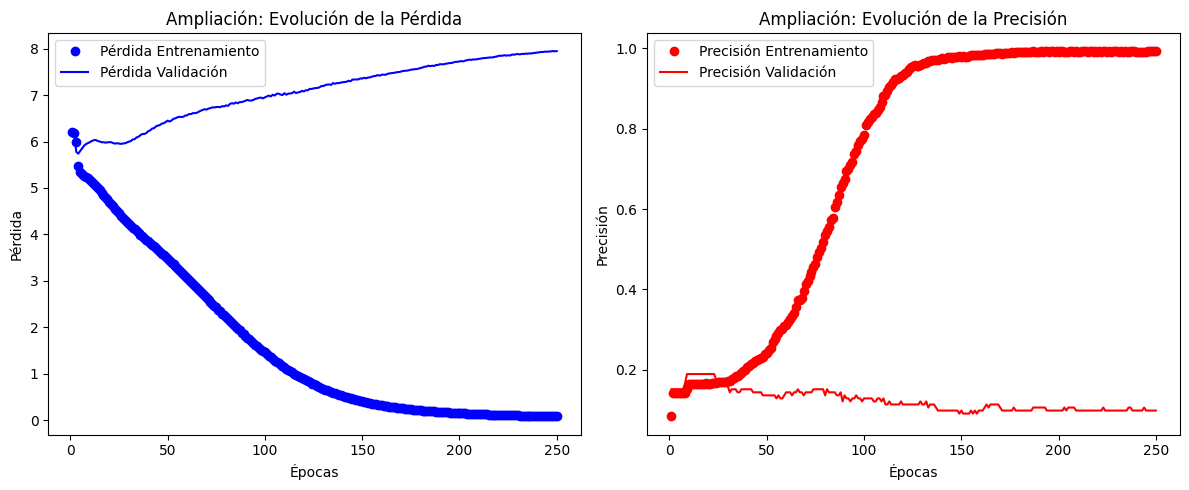

In [62]:
# Gráficas del entrenamiento con dataset ampliado

history_dict_amp = history_amp.history

loss_values_amp = history_dict_amp["loss"]
val_loss_values_amp = history_dict_amp["val_loss"]
acc_amp = history_dict_amp["accuracy"]
val_acc_amp = history_dict_amp["val_accuracy"]

epochs_amp = range(1, len(loss_values_amp) + 1)

plt.figure(figsize=(12, 5))

# Gráfica de pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs_amp, loss_values_amp, "bo", label="Pérdida Entrenamiento")
plt.plot(epochs_amp, val_loss_values_amp, "b", label="Pérdida Validación")
plt.title("Ampliación: Evolución de la Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()

# Gráfica de precisión
plt.subplot(1, 2, 2)
plt.plot(epochs_amp, acc_amp, "ro", label="Precisión Entrenamiento")
plt.plot(epochs_amp, val_acc_amp, "r", label="Precisión Validación")
plt.title("Ampliación: Evolución de la Precisión")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()

plt.tight_layout()
plt.show()

In [63]:
# Pruebas tras la ampliación

# Al haber re-adaptado el decoder_vectorizer, actualizamos los ids prohibidos.
TOKENS_PROHIBIDOS = ["", "[UNK]", START_TOKEN]

TOKENS_PROHIBIDOS_IDS = [
    decoder_vocab.index(token)
    for token in TOKENS_PROHIBIDOS
    if token in decoder_vocab
]


def decode_sequence_amp(input_seq):
    """
    Genera la respuesta del chatbot para una frase de entrada.

    Proceso:
      1. El encoder resume la pregunta en un vector de estado (h, c).
      2. Arrancamos el decoder con el token <start>.
      3. En cada paso, el decoder predice el siguiente token más probable.
      4. Ese token pasa a ser la entrada del siguiente paso (autoregresivo).
      5. Paramos al predecir <end> o al alcanzar MAX_LENGTH.
    """
    # 1. Codificar la pregunta → estados iniciales del decoder
    states_value = encoder_model(tf.constant([input_seq]), training=False)
    if not isinstance(states_value, list):
        states_value = list(states_value)

    # 2. Primer token de entrada del decoder: <start>
    #    Usamos el dict inverso (O(1)) en lugar de decoder_vocab.index() (O(n))
    start_id   = decoder_word2idx[START_TOKEN]
    target_seq = tf.constant([[start_id]], dtype=tf.int64)

    respuesta_tokens = []

    # 3. Bucle autoregresivo de generación
    for _ in range(MAX_LENGTH):
        outputs         = decoder_model([target_seq] + states_value, training=False)
        decoder_preds   = outputs[0]          # shape: (1, 1, vocab_size)
        h, c            = outputs[1], outputs[2]

        # Probabilidades del siguiente token como array numpy editable
        probs = decoder_preds[0, 0, :].numpy().copy()

        # Ponemos probabilidad −1 a los tokens prohibidos para que np.argmax
        # nunca los seleccione (más robusto que poner 0, pues todos podrían ser ≤ 0)
        for tid in TOKENS_PROHIBIDOS_IDS:
            probs[tid] = -1.0

        # Token con mayor probabilidad
        predicted_id   = int(np.argmax(probs))
        predicted_word = decoder_vocab[predicted_id]

        # Condición de parada: token de fin
        if predicted_word == END_TOKEN:
            break

        respuesta_tokens.append(predicted_word)

        # 4. El token predicho es la nueva entrada; los estados se propagan
        target_seq   = tf.constant([[predicted_id]], dtype=tf.int64)
        states_value = [h, c]

    return " ".join(respuesta_tokens)

frases_prueba_ampliacion = [
    # Frases del entrenamiento o muy parecidas
    "Hola",
    "Gracias",
    "Quién eres",
    "Necesito ayuda",
    "Tengo un error en Python",

    # Frases no exactamente iguales
    "Hola amigo",
    "Me puedes ayudar",
    "Estoy muy cansado",
    "Explícame algo de Keras",
    "Tengo que repasar",

    # Frases claramente fuera de distribución
    "Cuál es la capital de Francia",
    "Resuelve una integral",
    "Recomiéndame una película"
]

for frase in frases_prueba_ampliacion:
    print("Entrada:", frase)
    print("Salida :", decode_sequence_amp(frase))
    print("-" * 50)

Entrada: Hola
Salida : por no
--------------------------------------------------
Entrada: Gracias
Salida : mucho te
--------------------------------------------------
Entrada: Quién eres
Salida : mucho te
--------------------------------------------------
Entrada: Necesito ayuda
Salida : por no
--------------------------------------------------
Entrada: Tengo un error en Python
Salida : Hola en en No
--------------------------------------------------
Entrada: Hola amigo
Salida : En qué
--------------------------------------------------
Entrada: Me puedes ayudar
Salida : Hola puedo a
--------------------------------------------------
Entrada: Estoy muy cansado
Salida : En qué
--------------------------------------------------
Entrada: Explícame algo de Keras
Salida : Hola en No
--------------------------------------------------
Entrada: Tengo que repasar
Salida : En qué una
--------------------------------------------------
Entrada: Cuál es la capital de Francia
Salida : Hola en en
----

### Conclusiones

A primera vista podemos ver que el modelo funciona mucho peor que antes. Con 10 frases, el modelo tenía capacidad suficiente para memorizar (sobreajustar) las secuencias exactas y actuar como un diccionario. Al introducir 180 frases, hemos introducido demasiada variabilidad para que el modelo pueda simplemente memorizar todo. El modelo ha abandonado la memorización pura, pero el dataset sigue siendo insuficiente para que descubra las reglas gramaticales reales. Está en un punto en el que intenta generalizar, pero no lo consigue.

Podemos ver que la mayoría de salidas son una cadena de preposiciones y conjunciones. Esto es debido a que en 180 frases en español, estas palabras son estadísticamente las más frecuentes. Como el modelo no entiende el contexto, su decodificador apuesta por lo seguro y predice las palabras que más veces ha visto durante el entrenamiento. Ha aprendido que decir "en", "que" o "no" minimiza el error promedio mucho más que intentar usar sustantivos o verbos específicos.

De nuevo el modelo ha colapsado en unas pocas frases comodín que repite sin importar la longitud o intención de la pregunta. Ejemplos de esto son "En que una" o "Hola en no" que aparecen en muchas respuestas.

Podemos ver además que el modelo a veces repite palabras en las generaciones (como "Hola en No No" o "Hola en en No"). Esto nos lleva a pensar que el decodificador no está actualizando correctamente su estado oculto tras emitir un token. Una vez que predice "en", las probabilidades se atascan y vuelve a predecir "en", ignorando lo que acaba de escribir.

En resumen, parece ser que ampliar el dataset a un tamaño ligeramente mayor es incluso peor que tener uno extremadamente pequeño. Ya no tenemos ni una respuesta con sentido dado que el modelo no es capaz de memorizar todo el dataset, prediciendo patrones por pura frecuencia de aparición y no tanto por "entender" las frases o el contexto. Quizás con un número de épocas de entrenamiento extremadamente alto sea capaz de memorizar todo el dataset mejor pero visto el resultado anterior seguirá siendo poco útil como chatbot. Aumentando drásticamente el dataset y el entrenamiento podríamos llegar a obtener resultados mejores pero quizás seguirá siendo inútil para frases desconocidas (ya que le seguiría costando reconocer patrones).

# **Conclusiones y Limitaciones**

Añada una celda de texto final analizando los resultados. Comente específicamente:
1. ¿Qué sucede si introduce una frase que no estaba en el set de entrenamiento (ej: "Hola amigo")?
2. ¿Cuáles son las limitaciones de las redes recurrentes (LSTMs) frente a arquitecturas modernas como los Transformers (p.ej. BERT o GPT) para esta tarea?

Las conclusiones de cada experimento se han puesto al final de este para tener más cerca las salidas y que sea más fácil reconocer las conclusiones en las salidas del programa. Pasamos a responder a las preguntas planteadas:

1. Cuando introducimos una frase que no estaba en el conjunto de entrenamiento original, como "Hola amigo", el modelo se enfrenta a un problema fundamental de falta de generalización. En nuestro experimento, la salida fue "En qué". Esto ocurre por varios motivos:

- Problema de vocabulario (Out-Of-Vocabulary): Si la palabra "amigo" no apareció nunca en las 180 frases, el modelo no tiene una representación matemática (embedding) para ella, ignorándola o tratándola como ruido.

- Limitaciones del dataset: Al no tener suficientes datos para entender que "Hola" y "Hola amigo" comparten una intención semántica idéntica (un saludo), el modelo genera un vector de contexto completamente distinto.

- Caída en respuestas "por defecto": Ante la incertidumbre matemática generada por una entrada desconocida, el decodificador recurre a la secuencia de palabras más probable a nivel global en el dataset de entrenamiento (en este caso, arrancar con "En qué"), ignorando por completo el significado real de la pregunta.

2. Las redes recurrentes (como las LSTMs usadas clásicamente en Seq2Seq)presentan limitaciones bastante importantes frente a los modelos modernos basados en Transformers:

- El vector de contexto: Un Seq2Seq tradicional con LSTMs debe comprimir todo el significado de la frase de entrada en un único vector de tamaño fijo antes de pasarlo al decodificador. Para frases largas, esto provoca una pérdida de información masiva. Los Transformers solucionan esto mediante el mecanismo de Atención (Self-Attention), permitiendo al decodificador mirar directamente a cualquier palabra de la entrada original en cualquier momento.

- Procesamiento secuencial: Las LSTMs procesan la información palabra por palabra de forma secuencial (no puedes calcular la palabra 3 sin haber calculado la 2). Esto hace que el entrenamiento sea extremadamente lento. Los Transformers procesan todas las palabras de la secuencia simultáneamente, lo que permite aprovechar al máximo las GPUs modernas y entrenar con terabytes de texto.

- Pérdida de contexto a largo plazo: Las LSTMs pierden el "hilo" en textos largos. Los Transformers, gracias a la atención posicional, conectan dependencias a largo plazo de manera directa y sin degradación.

- Transferencia de aprendizaje (*Transfer Learning*): Las arquitecturas Transformer (como GPT o BERT) están diseñadas para pre-entrenarse en datasets gigantescos (todo internet) de forma no supervisada, adquiriendo una comprensión profunda del lenguaje antes de afinarse para tareas específicas. Nuestro modelo LSTM está aprendiendo español desde cero absoluto con solo 180 frases (como mucho).